In [1]:
import argparse
import hashlib
import os
os.chdir("/home/blessedg/Pathformer")
import warnings
from tqdm import tqdm
# import numpy as np
import deepmimo as dm
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import ConcatDataset, DataLoader

from dataset.dataloaders import PreTrainMySeqDataLoader
from multiscenario_direct_training_first_step_residual import (
    FirstStepResidualDataset,
    # FirstStepResidualPathDecoder,
    # evaluate_model,
    get_resume_checkpoint_path,
    load_best_checkpoint,
    resolve_scenarios,
    train_with_interactions,
)
from multiscenario_direct_training_first_step_residual_corridor import (
    build_first_step_assignments_with_corridor,
)
from scene_feature_utils import SceneFeatureBank
from types import SimpleNamespace, MethodType
import seaborn

In [2]:

csv_log_file = "muldims_weighted_first_step_residual_corridor_concat_results.csv"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(os.getcwd())
atten_glob_0 = None
atten_glob_final = None


/home/blessedg/Pathformer


In [3]:
@torch.no_grad()
def generate_paths_first_step_residual_batch(model, prompts, first_step_baselines, max_steps=25):
    global atten_glob_0
    global atten_glob_final
    model.eval()
    device = next(model.parameters()).device
    prompts = prompts.to(device)
    first_step_baselines = first_step_baselines.to(device)

    cur = torch.zeros(prompts.shape[0], 1, 7, device=device)
    inter_str = -1 * torch.ones(prompts.shape[0], 1, 4, device=device)

    outputs = []
    outputs_inter = []
    pathcounts = None

    for _ in range(max_steps):
        (
            d,
            p,
            _,
            _,
            ph,
            _,
            _,
            az,
            _,
            _,
            el,
            _,
            _,
            aod_az,
            _,
            _,
            aod_el,
            pathcounts,
            inter_logits,
        ) = model(prompts, cur, inter_str, first_step_baselines)
        print("Captured Attention Weights Shape:", model.backbone.decoder.layers[0].multihead_attn.attn_weights.shape)
        atten_glob_0 = model.backbone.decoder.layers[0].multihead_attn.attn_weights
        atten_glob_final = model.backbone.decoder.layers[-1].multihead_attn.attn_weights
        d_t = d[:, -1]
        p_t = p[:, -1]
        ph_t = ph[:, -1]
        az_t = az[:, -1]
        el_t = el[:, -1]
        aod_az_t = aod_az[:, -1]
        aod_el_t = aod_el[:, -1]
        inter_pred_t = (torch.sigmoid(inter_logits[:, -1]) > 0.5).float()

        next_path = torch.stack([d_t, p_t, ph_t, az_t, el_t, aod_az_t, aod_el_t], dim=-1)
        outputs.append(next_path)
        outputs_inter.append(inter_pred_t)
        cur = torch.cat([cur, next_path.unsqueeze(1)], dim=1)
        inter_str = torch.cat([inter_str, inter_pred_t.unsqueeze(1)], dim=1)

    return (
        torch.stack(outputs, dim=1).detach().cpu(),
        pathcounts.detach().cpu(),
        torch.stack(outputs_inter, dim=1).detach().cpu(),
    )

def evaluate_model(model, val_loader, max_generate=25):
    model.eval()
    delay_errors, power_errors, phase_errors = [], [], []
    az_errors, el_errors, path_length_rmses = [], [], []
    aod_az_errors, aod_el_errors = [], []
    delay_maes, power_maes, phase_maes = [], [], []
    az_maes, el_maes, path_length_maes = [], [], []
    aod_az_maes, aod_el_maes = [], []
    interaction_targets_all, interaction_preds_all = [], []

    def mean_std(values):
        if len(values) == 0:
            return 0.0, 0.0
        arr = np.asarray(values, dtype=np.float64)
        return float(np.mean(arr)), float(np.std(arr))

    with torch.no_grad():
        for prompts, paths, path_lengths, interactions, env, env_prop, path_padding_mask, first_step_baselines in tqdm(val_loader, desc="Evaluating", leave=True):
            prompts = prompts.cuda()
            paths = paths.cuda()
            path_lengths = path_lengths.cuda()
            interactions = interactions.cuda()
            first_step_baselines = first_step_baselines.cuda()

            generated, path_lengths_pred, inter_str_pred = generate_paths_first_step_residual_batch(
                model,
                prompts,
                first_step_baselines,
                max_steps=max_generate,
            )
            generated = generated.cuda()
            if path_lengths_pred.dim() > 1:
                path_lengths_pred = path_lengths_pred.squeeze(-1)

            for b in range(prompts.size(0)):
                n_valid = int(round(path_lengths[b].item() * 25))
                gt = paths[b][1:1 + n_valid, :7]
                gt_inter = interactions[b][1:1 + n_valid, :]
                T = min(len(gt), generated.size(1))
                pred = generated[b, :T]
                gt = gt[:T]
                pred_inter = inter_str_pred[b, :T]
                gt_inter = gt_inter[:T].detach().cpu()

                valid_interaction_mask = (gt_inter[:, 0] != -1)
                if valid_interaction_mask.any():
                    interaction_targets_all.append(gt_inter[valid_interaction_mask].numpy().astype(np.int32))
                    interaction_preds_all.append(pred_inter[valid_interaction_mask].numpy().astype(np.int32))

                delay_rmse = torch.mean((pred[:, 0] - gt[:, 0]) ** 2).sqrt().item()
                delay_mae = torch.mean(torch.abs(pred[:, 0] - gt[:, 0])).item()

                power_rmse = torch.mean(((pred[:, 1] / 0.01) - (gt[:, 1] / 0.01)) ** 2).sqrt().item()
                power_mae = torch.mean(torch.abs((pred[:, 1] / 0.01) - (gt[:, 1] / 0.01))).item()
                # print(f"delay_mae:{power_mae} vs {torch.mean(torch.abs((pred[:2, 1] / 0.01) - (gt[:2, 1] / 0.01))).item()}")

                phase_dist = ((pred[:, 2] / (np.pi / 180)) - (gt[:, 2] / (np.pi / 180)) + 180) % 360 - 180
                phase_rmse = torch.mean(phase_dist ** 2).sqrt().item()
                phase_mae = torch.mean(torch.abs(phase_dist)).item()

                az_dist = ((pred[:, 3] / (np.pi / 180)) - (gt[:, 3] / (np.pi / 180)) + 180) % 360 - 180
                el_dist = ((pred[:, 4] / (np.pi / 180)) - (gt[:, 4] / (np.pi / 180)) + 180) % 360 - 180
                aod_az_dist = ((pred[:, 5] / (np.pi / 180)) - (gt[:, 5] / (np.pi / 180)) + 180) % 360 - 180
                aod_el_dist = ((pred[:, 6] / (np.pi / 180)) - (gt[:, 6] / (np.pi / 180)) + 180) % 360 - 180
                az_rmse = torch.mean(az_dist ** 2).sqrt().item()
                el_rmse = torch.mean(el_dist ** 2).sqrt().item()
                aod_az_rmse = torch.mean(aod_az_dist ** 2).sqrt().item()
                aod_el_rmse = torch.mean(aod_el_dist ** 2).sqrt().item()
                az_mae = torch.mean(torch.abs(az_dist)).item()
                el_mae = torch.mean(torch.abs(el_dist)).item()
                aod_az_mae = torch.mean(torch.abs(aod_az_dist)).item()
                aod_el_mae = torch.mean(torch.abs(aod_el_dist)).item()

                path_len_pred_b = path_lengths_pred[b]
                length_rmse = torch.mean((path_len_pred_b - path_lengths[b]) ** 2).sqrt().item()
                length_mae = torch.mean(torch.abs(path_len_pred_b - path_lengths[b])).item()

                delay_errors.append(delay_rmse); power_errors.append(power_rmse); phase_errors.append(phase_rmse)
                az_errors.append(az_rmse); el_errors.append(el_rmse); path_length_rmses.append(length_rmse)
                aod_az_errors.append(aod_az_rmse); aod_el_errors.append(aod_el_rmse)
                delay_maes.append(delay_mae); power_maes.append(power_mae); phase_maes.append(phase_mae)
                az_maes.append(az_mae); el_maes.append(el_mae); path_length_maes.append(length_mae)
                aod_az_maes.append(aod_az_mae); aod_el_maes.append(aod_el_mae)

    if interaction_targets_all:
        targets = np.concatenate(interaction_targets_all, axis=0)
        preds = np.concatenate(interaction_preds_all, axis=0)
        avg_interaction_accuracy = accuracy_score(targets.reshape(-1), preds.reshape(-1))
        avg_interaction_f1 = f1_score(targets.reshape(-1), preds.reshape(-1), zero_division=0)
        interaction_accuracy_per_sample = [
            accuracy_score(target.reshape(-1), pred.reshape(-1))
            for target, pred in zip(interaction_targets_all, interaction_preds_all)
        ]
        interaction_f1_per_sample = [
            f1_score(target.reshape(-1), pred.reshape(-1), zero_division=0)
            for target, pred in zip(interaction_targets_all, interaction_preds_all)
        ]
        _, std_interaction_accuracy = mean_std(interaction_accuracy_per_sample)
        _, std_interaction_f1 = mean_std(interaction_f1_per_sample)
    else:
        avg_interaction_accuracy = 0.0
        avg_interaction_f1 = 0.0
        std_interaction_accuracy = 0.0
        std_interaction_f1 = 0.0

    avg_delay, std_delay = mean_std(delay_errors)
    avg_power, std_power = mean_std(power_errors)
    avg_phase, std_phase = mean_std(phase_errors)
    avg_az, std_az = mean_std(az_errors)
    avg_el, std_el = mean_std(el_errors)
    avg_aod_az, std_aod_az = mean_std(aod_az_errors)
    avg_aod_el, std_aod_el = mean_std(aod_el_errors)
    avg_path_length_rmse, std_path_length_rmse = mean_std(path_length_rmses)
    avg_delay_mae, std_delay_mae = mean_std(delay_maes)
    avg_power_mae, std_power_mae = mean_std(power_maes)
    avg_phase_mae, std_phase_mae = mean_std(phase_maes)
    avg_az_mae, std_az_mae = mean_std(az_maes)
    avg_el_mae, std_el_mae = mean_std(el_maes)
    avg_aod_az_mae, std_aod_az_mae = mean_std(aod_az_maes)
    avg_aod_el_mae, std_aod_el_mae = mean_std(aod_el_maes)
    avg_path_length_mae, std_path_length_mae = mean_std(path_length_maes)

    return (
        avg_delay, std_delay,
        avg_power, std_power,
        avg_phase, std_phase,
        avg_az, std_az,
        avg_el, std_el,
        avg_aod_az, std_aod_az,
        avg_aod_el, std_aod_el,
        avg_path_length_rmse, std_path_length_rmse,
        avg_interaction_accuracy, std_interaction_accuracy,
        avg_interaction_f1, std_interaction_f1,
        avg_delay_mae, std_delay_mae,
        avg_power_mae, std_power_mae,
        avg_phase_mae, std_phase_mae,
        avg_az_mae, std_az_mae,
        avg_el_mae, std_el_mae,
        avg_aod_az_mae, std_aod_az_mae,
        avg_aod_el_mae, std_aod_el_mae,
        avg_path_length_mae, std_path_length_mae,
    )


In [4]:
def patched_forward(self, query, key, value, *args, **kwargs):
    # Overwrite whatever 'need_weights' the parent layer tries to pass in
    kwargs['need_weights'] = True
    
    # Call the original forward implementation
    attn_output, attn_output_weights = self._original_forward(query, key, value, *args, **kwargs)
    
    # Store the weights in our global/outer dictionary
    # captured_attn['weights'] = attn_output_weights
    self.attn_weights = attn_output_weights
    return attn_output, attn_output_weights

class PathDecoder(nn.Module):
    def __init__(self, prompt_dim=6, hidden_dim=512, n_layers=6, n_heads=4,  max_T = 35, prefix_len=4, pad_value=500, include_aod=False):
        super().__init__()
        self.pad_value = pad_value
        self.hidden_dim = hidden_dim
        self.prefix_len = prefix_len
        self.max_T = max_T
        self.include_aod = include_aod
        # Project prompt → conditioning token
        # self.prompt_proj = nn.Linear(prompt_dim, hidden_dim)
        self.prompt_to_prefix = nn.Linear(prompt_dim, prefix_len * hidden_dim)
        # Path token embedding: delay, power, sin(phase), cos(phase), is_last
        self.path_in = nn.Linear(16 if include_aod else 12, hidden_dim)

        # Positional embedding for sequence steps
        self.pos_emb = nn.Embedding(max_T, hidden_dim)  # supports up to 25 paths

        # self.environment_embed = nn.Linear(4, hidden_dim)  # Example input size
        # self.environment_prop_embed = nn.Linear(6, hidden_dim)
        
        self.interaction_head = nn.Linear(hidden_dim, 4)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_dim,
            nhead=n_heads,
            dim_feedforward=4*hidden_dim,
            batch_first=True
        )
        
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)
        ##

        for layer in self.decoder.layers:
            layer.multihead_attn._original_forward =  layer.multihead_attn.forward
            layer.multihead_attn.forward = MethodType(patched_forward, layer.multihead_attn)
            
        # Output head: predict next (delay, power, phase_sin, phase_cos, is_stop)
        self.out_delay = nn.Sequential(
                    nn.Linear(hidden_dim, 1),
                    # nn.Sigmoid(),
                )
        
        self.out_power = nn.Sequential(
                    nn.Linear(hidden_dim, 1),
                )
        self.out = nn.Sequential(
                    nn.Linear(hidden_dim, hidden_dim),
                    nn.GELU(),
                    nn.Linear(hidden_dim, hidden_dim),
                    nn.GELU(),
                    nn.Linear(hidden_dim, 10 if include_aod else 6),
                    # nn.Tanh(),
                )
        self.pathcount_head = nn.Sequential(
            nn.Linear(prefix_len * hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, prompts, paths, interactions, **kwargs):
        """
        prompts: (B, prompt_dim)
        paths: (B, T, 4)
        interactions: (B,T,4)
        **kwargs: ignored (e.g. cluster_emb, cluster_pad_mask for compatibility with playground)
        environment: (B, 4)
        environment_properties: (B, T2, 6)
        Returns:
            delay_pred, power_pred, phase_sin_pred, phase_cos_pred,
            phase_pred, pathcounts, interaction_logits
        """

        # B, T2, _ = environment_properties.shape
        # env_embedding = self.environment_embed(environment).unsqueeze(1)  # (B, 1, hidden_dim)
        # env_prop_embedding = self.environment_prop_embed(environment_properties)  # (B, T2, hidden_dim)
        # self.env_len = 1 + T2

        # Convert prompt → prefix tokens
        # if pre_train:
        #     prefix_raw = self.prompt_to_prefix(prompts * 0.0) # Zero out input
        #     prefix = torch.zeros( (B, self.prefix_len, self.hidden_dim)).to("cuda")
        # else:



        B, T, _ = paths.shape
        prefix_raw = self.prompt_to_prefix(prompts)
        prefix = prefix_raw.view(B, self.prefix_len, self.hidden_dim)

        # Convert phase to sin/cos
        phase = paths[:,:,2]
        sinp = torch.sin(phase)
        cosp = torch.cos(phase)

        aoa_az = paths[:, :, 3]
        sin_az = torch.sin(aoa_az)
        cos_az = torch.cos(aoa_az)

        aoa_el = paths[:, :, 4]
        sin_el = torch.sin(aoa_el)
        cos_el = torch.cos(aoa_el)

        x_parts = [paths[:, :, 0], paths[:, :, 1], sinp, cosp, sin_az, cos_az, sin_el, cos_el]
        if self.include_aod:
            aod_az = paths[:, :, 5]
            sin_aod_az = torch.sin(aod_az)
            cos_aod_az = torch.cos(aod_az)
            aod_el = paths[:, :, 6]
            sin_aod_el = torch.sin(aod_el)
            cos_aod_el = torch.cos(aod_el)
            x_parts.extend([sin_aod_az, cos_aod_az, sin_aod_el, cos_aod_el])

        x = torch.stack(x_parts, dim=-1)


        interactions_clean = interactions.clone()
        interactions_clean[interactions_clean == -1] = 0

        x = torch.cat([x, interactions_clean], dim=-1)
        # Embed tokens
        x = self.path_in(x)   # (B, T, hidden)
         ## Append SOS embedding
        # x = torch.cat([env_embedding, env_prop_embedding, x], dim=1)

        total_len =   T
        pos = self.pos_emb(torch.arange(total_len, device=x.device))  # (T, hidden)

        x = x + pos
        # Conditioning prompt token

        

        # Construct causal mask
        causal_mask = torch.triu(torch.ones(total_len, total_len, device=x.device), diagonal=1).bool()

        # Decode
        h = self.decoder(
            tgt=x,
            memory=prefix,
            tgt_mask=causal_mask
        )

        h_paths = h[:, :, :]

        # Predict next-step parameters
        out = self.out(h_paths)

        delay_pred = self.out_delay(h_paths).squeeze(-1)
        power_pred = self.out_power(h_paths).squeeze(-1)
        phase_sin_pred = out[:, :, 0]
        phase_cos_pred = out[:, :, 1]
        phase_pred = torch.atan2(phase_sin_pred, phase_cos_pred)

        az_sin_pred = out[:, :, 2]
        az_cos_pred = out[:, :, 3]
        el_sin_pred = out[:, :, 4]
        el_cos_pred = out[:, :, 5]

        phase_pred = torch.atan2(phase_sin_pred, phase_cos_pred)
        az_pred = torch.atan2(az_sin_pred, az_cos_pred)
        el_pred = torch.atan2(el_sin_pred, el_cos_pred)
        interaction_logits = self.interaction_head(h_paths)
        ## path count prediction
        prefix_flat = prefix.reshape(B, -1)
        pathcounts = self.pathcount_head(prefix_flat)

        if self.include_aod:
            aod_az_sin_pred = out[:, :, 6]
            aod_az_cos_pred = out[:, :, 7]
            aod_el_sin_pred = out[:, :, 8]
            aod_el_cos_pred = out[:, :, 9]
            aod_az_pred = torch.atan2(aod_az_sin_pred, aod_az_cos_pred)
            aod_el_pred = torch.atan2(aod_el_sin_pred, aod_el_cos_pred)
            return (delay_pred, power_pred, phase_sin_pred, phase_cos_pred, phase_pred,
                az_sin_pred, az_cos_pred, az_pred, el_sin_pred, el_cos_pred, el_pred,
                aod_az_sin_pred, aod_az_cos_pred, aod_az_pred,
                aod_el_sin_pred, aod_el_cos_pred, aod_el_pred,
                pathcounts, interaction_logits)

        return (delay_pred, power_pred, phase_sin_pred, phase_cos_pred, phase_pred,
            az_sin_pred, az_cos_pred, az_pred, el_sin_pred, el_cos_pred, el_pred,
            pathcounts, interaction_logits)

    def forward_hidden(self, prompts, paths, interactions):
        """
        Same as forward but returns (h_paths, prefix_flat) before output heads.
        Used by wrappers that need hidden state (e.g. cluster MLP head).
        """
        B, T, _ = paths.shape
        prefix_raw = self.prompt_to_prefix(prompts)
        prefix = prefix_raw.view(B, self.prefix_len, self.hidden_dim)
        phase = paths[:, :, 2]
        sinp = torch.sin(phase)
        cosp = torch.cos(phase)
        aoa_az = paths[:, :, 3]
        sin_az = torch.sin(aoa_az)
        cos_az = torch.cos(aoa_az)
        aoa_el = paths[:, :, 4]
        sin_el = torch.sin(aoa_el)
        cos_el = torch.cos(aoa_el)
        x_parts = [paths[:, :, 0], paths[:, :, 1], sinp, cosp, sin_az, cos_az, sin_el, cos_el]
        if self.include_aod:
            aod_az = paths[:, :, 5]
            sin_aod_az = torch.sin(aod_az)
            cos_aod_az = torch.cos(aod_az)
            aod_el = paths[:, :, 6]
            sin_aod_el = torch.sin(aod_el)
            cos_aod_el = torch.cos(aod_el)
            x_parts.extend([sin_aod_az, cos_aod_az, sin_aod_el, cos_aod_el])
        x = torch.stack(x_parts, dim=-1)
        interactions_clean = interactions.clone()
        interactions_clean[interactions_clean == -1] = 0
        x = torch.cat([x, interactions_clean], dim=-1)
        x = self.path_in(x)
        total_len = T
        pos = self.pos_emb(torch.arange(total_len, device=x.device))
        x = x + pos
        causal_mask = torch.triu(torch.ones(total_len, total_len, device=x.device), diagonal=1).bool()
        h = self.decoder(tgt=x, memory=prefix, tgt_mask=causal_mask)
        h_paths = h[:, :, :]
        prefix_flat = prefix.reshape(B, -1)
        return h_paths, prefix_flat


class FirstStepResidualPathDecoder(torch.nn.Module):
    def __init__(self, prompt_dim=10, hidden_dim=512, n_layers=8, n_heads=8, max_T=26, prefix_len=4, pad_value=0, include_aod=True):
        super().__init__()
        self.backbone = PathDecoder(
            prompt_dim=prompt_dim,
            hidden_dim=hidden_dim,
            n_layers=n_layers,
            n_heads=n_heads,
            max_T=max_T,
            prefix_len=prefix_len,
            pad_value=pad_value,
            include_aod=include_aod,
        )
        self.first_delay_residual_head = torch.nn.Linear(hidden_dim, 1)
        self.first_power_residual_head = torch.nn.Linear(hidden_dim, 1)

    def forward(self, prompts, paths, interactions, first_step_baseline):
        h_paths, prefix_flat = self.backbone.forward_hidden(prompts, paths, interactions)
        out = self.backbone.out(h_paths)

        delay_pred = self.backbone.out_delay(h_paths).squeeze(-1)
        power_pred = self.backbone.out_power(h_paths).squeeze(-1)

        delay_pred = delay_pred.clone()
        power_pred = power_pred.clone()
        delay_pred[:, 0] = first_step_baseline[:, 0] + self.first_delay_residual_head(h_paths[:, 0, :]).squeeze(-1)
        power_pred[:, 0] = first_step_baseline[:, 1] + self.first_power_residual_head(h_paths[:, 0, :]).squeeze(-1)

        phase_sin_pred = out[:, :, 0]
        phase_cos_pred = out[:, :, 1]
        az_sin_pred = out[:, :, 2]
        az_cos_pred = out[:, :, 3]
        el_sin_pred = out[:, :, 4]
        el_cos_pred = out[:, :, 5]
        aod_az_sin_pred = out[:, :, 6]
        aod_az_cos_pred = out[:, :, 7]
        aod_el_sin_pred = out[:, :, 8]
        aod_el_cos_pred = out[:, :, 9]

        phase_pred = torch.atan2(phase_sin_pred, phase_cos_pred)
        az_pred = torch.atan2(az_sin_pred, az_cos_pred)
        el_pred = torch.atan2(el_sin_pred, el_cos_pred)
        aod_az_pred = torch.atan2(aod_az_sin_pred, aod_az_cos_pred)
        aod_el_pred = torch.atan2(aod_el_sin_pred, aod_el_cos_pred)
        interaction_logits = self.backbone.interaction_head(h_paths)
        pathcounts = self.backbone.pathcount_head(prefix_flat)

        return (
            delay_pred,
            power_pred,
            phase_sin_pred,
            phase_cos_pred,
            phase_pred,
            az_sin_pred,
            az_cos_pred,
            az_pred,
            el_sin_pred,
            el_cos_pred,
            el_pred,
            aod_az_sin_pred,
            aod_az_cos_pred,
            aod_az_pred,
            aod_el_sin_pred,
            aod_el_cos_pred,
            aod_el_pred,
            pathcounts,
            interaction_logits,
        )



In [5]:
def run_scenario(scenario, args):
    dataset = dm.load(scenario)
    config = {
        "BATCH_SIZE": 128,
        "PAD_VALUE": 0,
        "LR": 2e-5,
        "epochs": 300,
        "interaction_weight": 0.01,
        "experiment": f"first_step_residual_corridor_{scenario}",
        "hidden_dim": 512,
        "n_layers": 8,
        "n_heads": 8,
        "time_step_weighted": False,
        "TARGET_NOISE_PROB": args.noise_prob,
        "TARGET_NOISE_PARAMS": None,
    }

    base_train = PreTrainMySeqDataLoader(dataset, train=True, split_by="user", sort_by="power", normalizers=None, apply_normalizers=[], pad_value=config["PAD_VALUE"], include_aod=True)
    base_val = PreTrainMySeqDataLoader(dataset, train=False, split_by="user", sort_by="power", normalizers=None, apply_normalizers=[], pad_value=config["PAD_VALUE"], include_aod=True)

    scene_bank = SceneFeatureBank.from_dataset(dataset, use_material_features=args.use_material_features)
    train_aug_prompts, train_baselines, val_aug_prompts, val_baselines = build_first_step_assignments_with_corridor(
        base_train,
        base_val,
        scene_bank,
        n_clusters=args.n_clusters,
        nearest_k=args.nearest_k,
        corridor_k=args.corridor_k,
        corridor_bins=args.corridor_bins,
    )

    train_data = FirstStepResidualDataset(base_train, train_aug_prompts, train_baselines)
    val_data = FirstStepResidualDataset(base_val, val_aug_prompts, val_baselines)
    train_loader = DataLoader(train_data, batch_size=config["BATCH_SIZE"], shuffle=True, collate_fn=train_data.collate_fn)
    val_loader = DataLoader(val_data, batch_size=config["BATCH_SIZE"], shuffle=False, collate_fn=val_data.collate_fn)

    prompt_dim = int(train_aug_prompts[0].numel())
    model = FirstStepResidualPathDecoder(prompt_dim=prompt_dim, hidden_dim=config["hidden_dim"], n_layers=config["n_layers"], n_heads=config["n_heads"]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["LR"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=25, T_mult=1, eta_min=1e-8)

    os.makedirs(args.checkpoint_dir, exist_ok=True)
    checkpoint_path = os.path.join(args.checkpoint_dir, f"{config['experiment']}_best_model_checkpoint.pth")
    resume_checkpoint_path = get_resume_checkpoint_path(checkpoint_path)

    if not args.skip_train:
        train_with_interactions(model, train_loader, val_loader, config, base_train, optimizer, scheduler, checkpoint_path, resume_checkpoint_path=resume_checkpoint_path)

    _, best_loss = load_best_checkpoint(model, checkpoint_path)
    results = evaluate_model(model, val_loader)
    (
        avg_delay,
        std_delay,
        avg_power,
        std_power,
        avg_phase,
        std_phase,
        avg_az,
        std_az,
        avg_el,
        std_el,
        avg_aod_az,
        std_aod_az,
        avg_aod_el,
        std_aod_el,
        avg_path_length_rmse,
        std_path_length_rmse,
        avg_interaction_accuracy,
        std_interaction_accuracy,
        avg_interaction_f1,
        std_interaction_f1,
        avg_delay_mae,
        std_delay_mae,
        avg_power_mae,
        std_power_mae,
        avg_phase_mae,
        std_phase_mae,
        avg_az_mae,
        std_az_mae,
        avg_el_mae,
        std_el_mae,
        avg_aod_az_mae,
        std_aod_az_mae,
        avg_aod_el_mae,
        std_aod_el_mae,
        avg_path_length_mae,
        std_path_length_mae,
    ) = results
    row = {
        "scenario": scenario,
        "n_clusters": args.n_clusters,
        "nearest_k": args.nearest_k,
        "corridor_k": args.corridor_k,
        "corridor_bins": args.corridor_bins,
        "prompt_dim": prompt_dim,
        "use_material_features": args.use_material_features,
        "noise_prob": args.noise_prob,
        "delay_rmse": avg_delay,
        "delay_rmse_std": std_delay,
        "power_rmse": avg_power,
        "power_rmse_std": std_power,
        "phase_rmse": avg_phase,
        "phase_rmse_std": std_phase,
        "az_rmse": avg_az,
        "az_rmse_std": std_az,
        "el_rmse": avg_el,
        "el_rmse_std": std_el,
        "aod_az_rmse": avg_aod_az,
        "aod_az_rmse_std": std_aod_az,
        "aod_el_rmse": avg_aod_el,
        "aod_el_rmse_std": std_aod_el,
        "path_length_rmse": avg_path_length_rmse,
        "path_length_rmse_std": std_path_length_rmse,
        "interaction_accuracy": avg_interaction_accuracy,
        "interaction_accuracy_std": std_interaction_accuracy,
        "interaction_f1": avg_interaction_f1,
        "interaction_f1_std": std_interaction_f1,
        "delay_mae": avg_delay_mae,
        "delay_mae_std": std_delay_mae,
        "power_mae": avg_power_mae,
        "power_mae_std": std_power_mae,
        "phase_mae": avg_phase_mae,
        "phase_mae_std": std_phase_mae,
        "avg_az_mae": avg_az_mae,
        "avg_az_mae_std": std_az_mae,
        "avg_el_mae": avg_el_mae,
        "avg_el_mae_std": std_el_mae,
        "avg_aod_az_mae": avg_aod_az_mae,
        "avg_aod_az_mae_std": std_aod_az_mae,
        "avg_aod_el_mae": avg_aod_el_mae,
        "avg_aod_el_mae_std": std_aod_el_mae,
        "path_length_mae": avg_path_length_mae,
        "path_length_mae_std": std_path_length_mae,
        "best_val_loss": best_loss.item() if hasattr(best_loss, "item") else best_loss,
    }
    # pd.DataFrame([row]).to_csv(args.csv_log_file, mode="a", index=False, header=not os.path.exists(args.csv_log_file))
    print(f"✓ Results for {scenario} saved to {row}")



In [6]:
args = SimpleNamespace(
    scenario = "city_47_chicago_3p5",
    shard_index=None,
    num_shards=None,
    csv_log_file=csv_log_file,
    checkpoint_dir="checkpoints_first_step_residual_corridor",
    experiment_name=None,
    noise_prob=0.0,
    skip_train=True,                       # Boolean instead of action="store_true"
    n_clusters=25,
    nearest_k=5,
    corridor_k=5,
    corridor_bins=8,
    use_material_features=True              # Incorporates your set_defaults(True)
)

In [7]:
run_scenario("city_47_chicago_3p5", args)

Loading TXRX PAIR: TXset 1 (tx_idx 0) & RXset 0 (rx_idxs 83664)


Evaluating:   0%|                                                                                                                                                                                                  | 0/45 [00:00<?, ?it/s]

Captured Attention Weights Shape: torch.Size([128, 1, 4])
Captured Attention Weights Shape: torch.Size([128, 2, 4])
Captured Attention Weights Shape: torch.Size([128, 3, 4])
Captured Attention Weights Shape: torch.Size([128, 4, 4])
Captured Attention Weights Shape: torch.Size([128, 5, 4])
Captured Attention Weights Shape: torch.Size([128, 6, 4])
Captured Attention Weights Shape: torch.Size([128, 7, 4])
Captured Attention Weights Shape: torch.Size([128, 8, 4])
Captured Attention Weights Shape: torch.Size([128, 9, 4])
Captured Attention Weights Shape: torch.Size([128, 10, 4])
Captured Attention Weights Shape: torch.Size([128, 11, 4])
Captured Attention Weights Shape: torch.Size([128, 12, 4])
Captured Attention Weights Shape: torch.Size([128, 13, 4])
Captured Attention Weights Shape: torch.Size([128, 14, 4])
Captured Attention Weights Shape: torch.Size([128, 15, 4])
Captured Attention Weights Shape: torch.Size([128, 16, 4])
Captured Attention Weights Shape: torch.Size([128, 17, 4])
Captur

Evaluating:   0%|                                                                                                                                                                                                  | 0/45 [00:00<?, ?it/s]


NameError: name 'np' is not defined

<Axes: >

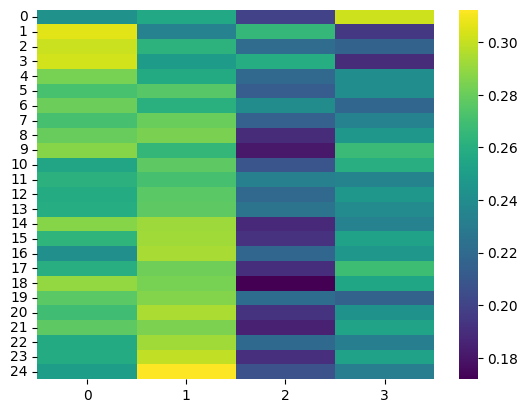

In [10]:
seaborn.heatmap(atten_glob_final.cpu()[0], cmap="viridis")

<Axes: >

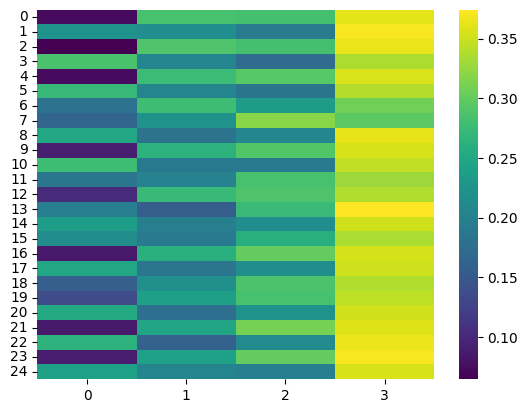

In [11]:
seaborn.heatmap(atten_glob_final.cpu()[1], cmap="viridis")


In [13]:
decoder_layer.multihead_attn.need_weights = True

In [14]:
captured = {}
def hook_fn(module, input, output):
    captured["attn_scores"] = output[1]
    '''
    attn_output, self_attn_weights = decoder_layer.self_attn(
        tgt, tgt, tgt, 
        attn_mask=None, 
        key_padding_mask=None, 
        need_weights=True  # <--- CRITICAL
    )
    '''

hook_handle = decoder_layer.multihead_attn.register_forward_hook(hook_fn)


#  normal forward pass
# batch_size=2, sequence_length=5, embedding_dim=64
tgt = torch.randn(5, 2, 64)
memory = torch.randn(10, 2, 64)
out = decoder_layer(tgt, memory)

# 
print("Captured Attention Weights Shape:", captured['attn_scores'].shape)

# Don't forget to remove the hook when done to prevent memory leaks
# hook_handle.remove()

AttributeError: 'NoneType' object has no attribute 'shape'

In [19]:
import torch
import torch.nn as nn

captured_attn = {}

# 1. Define a replacement forward function that forces need_weights=True
def patched_forward(self, query, key, value, *args, **kwargs):
    # Overwrite whatever 'need_weights' the parent layer tries to pass in
    kwargs['need_weights'] = True
    
    # Call the original forward implementation
    attn_output, attn_output_weights = self._original_forward(query, key, value, *args, **kwargs)
    
    # Store the weights in our global/outer dictionary
    captured_attn['weights'] = attn_output_weights
    
    return attn_output, attn_output_weights

# 2. Setup your layer
decoder_layer = nn.TransformerDecoderLayer(d_model=64, nhead=8)
 
# 3. Save the original forward method, then swap it with our patched version
decoder_layer.multihead_attn._original_forward = decoder_layer.multihead_attn.forward
decoder_layer.multihead_attn.forward = patched_forward.__get__(decoder_layer.multihead_attn)

#patched_forward.__get__(decoder_layer.multihead_attn) makes patched_forward to be glue to the object (decoder_layer.multihead_attn)

# 4. Run your normal forward pass
tgt = torch.randn(5, 2, 64)
memory = torch.randn(10, 2, 64)
out = decoder_layer(tgt, memory)

# 5. It successfully captures the shape now!
print("Captured Attention Weights Shape:", captured_attn['weights'].shape)
# Expected Output: torch.Size([2, 5, 10]) -> [batch_size, target_len, source_len]

# 6. Clean up: Restore the original forward method when done
decoder_layer.multihead_attn.forward = decoder_layer.multihead_attn._original_forward
delattr(decoder_layer.multihead_attn, '_original_forward')

Captured Attention Weights Shape: torch.Size([2, 5, 10])


In [25]:
#Monkey Patching 1.
class Dummy:
    def __init__(self):
        self.x = 5

    def square_orig(self):
        pass



def square(self):
    print(self.x**2)


me = Dummy()

me.square_orig = square.__get__(me)
# me.square_orig()

del me
## Monkey Patching
        
import types

# Instead of:
# obj.method = func.__get__(obj, Class)

# Developers write:
# obj.method = types.MethodType(func, obj)

me = Dummy()
me.square_orig = types.MethodType(square, me)
me.square_orig()

25


In [39]:
decoder_layer = nn.TransformerDecoderLayer(d_model=64, nhead=8)
decoder = nn.TransformerDecoder(decoder_layer, num_layers=5)

def patched_forward(self, query, key, value, *args, **kwargs):
    # Overwrite whatever 'need_weights' the parent layer tries to pass in
    kwargs['need_weights'] = True
    
    # Call the original forward implementation
    attn_output, attn_output_weights = self._original_forward(query, key, value, *args, **kwargs)
    
    # Store the weights in our global/outer dictionary
    # captured_attn['weights'] = attn_output_weights
    self.attn_weights = attn_output_weights
    return attn_output, attn_output_weights

In [40]:
for layer in decoder.layers:
    layer.multihead_attn._original_forward =  layer.multihead_attn.forward
    layer.multihead_attn.forward = types.MethodType(patched_forward, layer.multihead_attn)
    

In [43]:
tgt = torch.randn(5, 2, 64)
memory = torch.randn(10, 2, 64)
out = decoder(tgt, memory)
print("Captured Attention Weights Shape:", decoder.layers[0].multihead_attn.attn_weights.shape)

Captured Attention Weights Shape: torch.Size([2, 5, 10])


In [49]:

plt.plot(decoder.layers[0].multihead_attn.attn_weights[0])

NameError: name 'plt' is not defined

In [46]:
decoder.layers[0].multihead_attn.attn_weights

tensor([[0.0959, 0.0997, 0.1391, 0.1015, 0.0914, 0.0941, 0.1039, 0.0845, 0.0990,
         0.1250],
        [0.0944, 0.0876, 0.1079, 0.0822, 0.0821, 0.0770, 0.1145, 0.1593, 0.1212,
         0.1281],
        [0.1142, 0.1011, 0.1329, 0.0774, 0.0692, 0.1047, 0.1097, 0.0983, 0.1127,
         0.0882],
        [0.0800, 0.1016, 0.0930, 0.0895, 0.0863, 0.0673, 0.1117, 0.1231, 0.1495,
         0.0935],
        [0.0359, 0.1036, 0.1159, 0.1030, 0.0983, 0.1203, 0.0854, 0.0992, 0.0864,
         0.1198]], grad_fn=<SelectBackward0>)

In [24]:
atten_glob_final.shape

torch.Size([128, 25, 4])